In [1]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    
    if len(files) > 0:
        
        print("\n", root)
        print("Files:", files[:10])


 /kaggle/input/datasets/raddar/chest-xrays-indiana-university
Files: ['indiana_projections.csv', 'indiana_reports.csv']

 /kaggle/input/datasets/raddar/chest-xrays-indiana-university/images/images_normalized
Files: ['349_IM-1697-2001.dcm.png', '607_IM-2196-1001.dcm.png', '2832_IM-1249-2001.dcm.png', '699_IM-2263-2001.dcm.png', '1931_IM-0602-2001.dcm.png', '947_IM-2442-2001.dcm.png', '2932_IM-1335-1001.dcm.png', '2303_IM-0882-1001.dcm.png', '291_IM-1313-2001.dcm.png', '1790_IM-0515-1001.dcm.png']


In [2]:
import pandas as pd

REPORTS_PATH = "/kaggle/input/datasets/raddar/chest-xrays-indiana-university/indiana_reports.csv"
PROJECTIONS_PATH = "/kaggle/input/datasets/raddar/chest-xrays-indiana-university/indiana_projections.csv"

reports_df = pd.read_csv(REPORTS_PATH)
projections_df = pd.read_csv(PROJECTIONS_PATH)

print("Reports Shape:", reports_df.shape)
print("Projections Shape:", projections_df.shape)

Reports Shape: (3851, 8)
Projections Shape: (7466, 3)


In [3]:
print("REPORT COLUMNS")
print(reports_df.columns)

reports_df.head()

REPORT COLUMNS
Index(['uid', 'MeSH', 'Problems', 'image', 'indication', 'comparison',
       'findings', 'impression'],
      dtype='object')


,uid,MeSH,Problems,image,indication,comparison,findings,impression
0,1,normal,normal,Xray Chest PA and Lateral,Positive TB test,None.,The cardiac silhouette and mediastinum size ar...,Normal chest x-XXXX.
1,2,Cardiomegaly/borderline;Pulmonary Artery/enlarged,Cardiomegaly;Pulmonary Artery,"Chest, 2 views, frontal and lateral",Preop bariatric surgery.,None.,Borderline cardiomegaly. Midline sternotomy XX...,No acute pulmonary findings.
2,3,normal,normal,Xray Chest PA and Lateral,"rib pain after a XXXX, XXXX XXXX steps this XX...",NaN,NaN,"No displaced rib fractures, pneumothorax, or p..."
3,4,"Pulmonary Disease, Chronic Obstructive;Bullous...","Pulmonary Disease, Chronic Obstructive;Bullous...","PA and lateral views of the chest XXXX, XXXX a...",XXXX-year-old XXXX with XXXX.,None available,There are diffuse bilateral interstitial and a...,1. Bullous emphysema and interstitial fibrosis...
4,5,Osteophyte/thoracic vertebrae/multiple/small;T...,Osteophyte;Thickening;Lung,Xray Chest PA and Lateral,Chest and nasal congestion.,NaN,The cardiomediastinal silhouette and pulmonary...,No acute cardiopulmonary abnormality.


In [4]:
print("PROJECTION COLUMNS")
print(projections_df.columns)

projections_df.head()

PROJECTION COLUMNS
Index(['uid', 'filename', 'projection'], dtype='object')


,uid,filename,projection
0,1,1_IM-0001-4001.dcm.png,Frontal
1,1,1_IM-0001-3001.dcm.png,Lateral
2,2,2_IM-0652-1001.dcm.png,Frontal
3,2,2_IM-0652-2001.dcm.png,Lateral
4,3,3_IM-1384-1001.dcm.png,Frontal


In [5]:
print("REPORTS")

print(
    reports_df.isnull()
    .sum()
)

print("\nPROJECTIONS")

print(
    projections_df.isnull()
    .sum()
)

REPORTS
uid              0
MeSH             0
Problems         0
image            0
indication      86
comparison    1166
findings       514
impression      31
dtype: int64

PROJECTIONS
uid           0
filename      0
projection    0
dtype: int64


In [6]:
for col in reports_df.columns:

    print("="*50)
    print(col)
    print("="*50)

    print(
        reports_df[col]
        .iloc[0]
    )

    print()

uid
1

MeSH
normal

Problems
normal

image
Xray Chest PA and Lateral

indication
Positive TB test

comparison
None.

findings
The cardiac silhouette and mediastinum size are within normal limits. There is no pulmonary edema. There is no focal consolidation. There are no XXXX of a pleural effusion. There is no evidence of pneumothorax.

impression
Normal chest x-XXXX.



In [7]:
from collections import Counter
import re

all_text = (
    reports_df["findings"]
    .fillna("")
    .str.lower()
)

keywords = [
    "pneumonia",
    "effusion",
    "atelectasis",
    "cardiomegaly",
    "edema",
    "nodule",
    "mass",
    "pneumothorax",
    "emphysema",
    "hernia",
    "normal"
]

for word in keywords:

    count = all_text.str.contains(
        word,
        na=False
    ).sum()

    print(
        f"{word}: {count}"
    )

pneumonia: 129
effusion: 2570
atelectasis: 221
cardiomegaly: 134
edema: 193
nodule: 204
mass: 134
pneumothorax: 2367
emphysema: 74
hernia: 44
normal: 2961


In [8]:
print(
    reports_df["MeSH"]
    .value_counts()
    .head(30)
)

MeSH
normal                                                         1379
No Indexing                                                      92
Lung/hypoinflation                                               44
Thoracic Vertebrae/degenerative/mild                             29
Thoracic Vertebrae/degenerative                                  23
Spine/degenerative                                               19
Spine/degenerative/mild                                          18
Cardiomegaly/mild                                                17
Spondylosis/thoracic vertebrae                                   17
Granulomatous Disease                                            16
Lung/hyperdistention                                             15
Lung/hypoinflation/mild                                           9
Lung/hypoinflation;Markings/bronchovascular                       9
Catheters, Indwelling/right                                       9
Atherosclerosis/aorta                      

In [9]:
print(
    reports_df["Problems"]
    .value_counts()
    .head(30)
)

Problems
normal                            1379
No Indexing                         92
Lung                                86
Calcified Granuloma                 84
Thoracic Vertebrae                  59
Spine                               41
Calcinosis                          39
Opacity                             35
Cardiomegaly                        29
Scoliosis                           28
Spondylosis                         20
Surgical Instruments                20
Catheters, Indwelling               19
Osteophyte                          19
Granulomatous Disease               18
Fractures, Bone                     17
Nodule                              14
Lung;Markings                       13
Aorta, Thoracic                     12
Aorta                               12
Cicatrix                            11
Foreign Bodies                      11
Atherosclerosis                     11
Markings                            11
Implanted Medical Device            10
Calcified Granul

In [10]:
import random

for _ in range(5):

    idx = random.randint(
        0,
        len(reports_df)-1
    )

    print("="*100)

    print("MeSH:")
    print(
        reports_df.loc[idx,"MeSH"]
    )

    print("\nProblems:")
    print(
        reports_df.loc[idx,"Problems"]
    )

    print("\nFindings:")
    print(
        reports_df.loc[idx,"findings"]
    )

    print("\nImpression:")
    print(
        reports_df.loc[idx,"impression"]
    )

    print("\n")

MeSH:
normal

Problems:
normal

Findings:
nan

Impression:
Comparison XXXX, XXXX Clear lungs. No effusions. Unremarkable mediastinal contour. No acute cardiopulmonary abnormality identified.. Stable chest.


MeSH:
Opacity/lung/base/right/reticular/multiple;Lung/hypoinflation;Pulmonary Atelectasis/base/right

Problems:
Opacity;Lung;Pulmonary Atelectasis

Findings:
nan

Impression:
Anticipated senescent changes with grossly clear lungs. No effusions or CHF identified. A few scant reticular opacities in right lung base XXXX hypoventilation and foci of subsegmental atelectasis. No XXXX acute abnormalities since the previous chest radiograph.


MeSH:
normal

Problems:
normal

Findings:
nan

Impression:
Heart size is normal the lungs are clear


MeSH:
Calcinosis/abdomen/left/severe

Problems:
Calcinosis

Findings:
nan

Impression:
[&lt;The heart size and cardiomediastinal silhouette are stable and within normal limits. Pulmonary vasculature appears normal. There is no focal air space consoli

In [11]:
reports_df["label"] = (
    reports_df["Problems"]
    .str.lower()
    .apply(
        lambda x:
        0 if x == "normal"
        else 1
    )
)

print(
    reports_df["label"]
    .value_counts()
)

label
1    2472
0    1379
Name: count, dtype: int64


In [12]:
merged_df = projections_df.merge(
    reports_df,
    on="uid",
    how="inner"
)

print(
    merged_df.shape
)

merged_df.head()

(7466, 11)


,uid,filename,projection,MeSH,Problems,image,indication,comparison,findings,impression,label
0,1,1_IM-0001-4001.dcm.png,Frontal,normal,normal,Xray Chest PA and Lateral,Positive TB test,None.,The cardiac silhouette and mediastinum size ar...,Normal chest x-XXXX.,0
1,1,1_IM-0001-3001.dcm.png,Lateral,normal,normal,Xray Chest PA and Lateral,Positive TB test,None.,The cardiac silhouette and mediastinum size ar...,Normal chest x-XXXX.,0
2,2,2_IM-0652-1001.dcm.png,Frontal,Cardiomegaly/borderline;Pulmonary Artery/enlarged,Cardiomegaly;Pulmonary Artery,"Chest, 2 views, frontal and lateral",Preop bariatric surgery.,None.,Borderline cardiomegaly. Midline sternotomy XX...,No acute pulmonary findings.,1
3,2,2_IM-0652-2001.dcm.png,Lateral,Cardiomegaly/borderline;Pulmonary Artery/enlarged,Cardiomegaly;Pulmonary Artery,"Chest, 2 views, frontal and lateral",Preop bariatric surgery.,None.,Borderline cardiomegaly. Midline sternotomy XX...,No acute pulmonary findings.,1
4,3,3_IM-1384-1001.dcm.png,Frontal,normal,normal,Xray Chest PA and Lateral,"rib pain after a XXXX, XXXX XXXX steps this XX...",NaN,NaN,"No displaced rib fractures, pneumothorax, or p...",0


In [13]:
IMAGE_DIR = (
    "/kaggle/input/datasets/raddar/"
    "chest-xrays-indiana-university/"
    "images/images_normalized"
)

import os

merged_df["image_path"] = (
    merged_df["filename"]
    .apply(
        lambda x:
        os.path.join(
            IMAGE_DIR,
            x
        )
    )
)

merged_df.head()

,uid,filename,projection,MeSH,Problems,image,indication,comparison,findings,impression,label,image_path
0,1,1_IM-0001-4001.dcm.png,Frontal,normal,normal,Xray Chest PA and Lateral,Positive TB test,None.,The cardiac silhouette and mediastinum size ar...,Normal chest x-XXXX.,0,/kaggle/input/datasets/raddar/chest-xrays-indi...
1,1,1_IM-0001-3001.dcm.png,Lateral,normal,normal,Xray Chest PA and Lateral,Positive TB test,None.,The cardiac silhouette and mediastinum size ar...,Normal chest x-XXXX.,0,/kaggle/input/datasets/raddar/chest-xrays-indi...
2,2,2_IM-0652-1001.dcm.png,Frontal,Cardiomegaly/borderline;Pulmonary Artery/enlarged,Cardiomegaly;Pulmonary Artery,"Chest, 2 views, frontal and lateral",Preop bariatric surgery.,None.,Borderline cardiomegaly. Midline sternotomy XX...,No acute pulmonary findings.,1,/kaggle/input/datasets/raddar/chest-xrays-indi...
3,2,2_IM-0652-2001.dcm.png,Lateral,Cardiomegaly/borderline;Pulmonary Artery/enlarged,Cardiomegaly;Pulmonary Artery,"Chest, 2 views, frontal and lateral",Preop bariatric surgery.,None.,Borderline cardiomegaly. Midline sternotomy XX...,No acute pulmonary findings.,1,/kaggle/input/datasets/raddar/chest-xrays-indi...
4,3,3_IM-1384-1001.dcm.png,Frontal,normal,normal,Xray Chest PA and Lateral,"rib pain after a XXXX, XXXX XXXX steps this XX...",NaN,NaN,"No displaced rib fractures, pneumothorax, or p...",0,/kaggle/input/datasets/raddar/chest-xrays-indi...


In [14]:
exists = merged_df["image_path"].apply(
    os.path.exists
)

print(
    exists.value_counts()
)

image_path
True    7466
Name: count, dtype: int64


In [15]:
frontal_df = merged_df[
    merged_df["projection"]
    == "Frontal"
].copy()

print(
    frontal_df.shape
)

frontal_df["label"].value_counts()

(3818, 12)


label
1    2431
0    1387
Name: count, dtype: int64

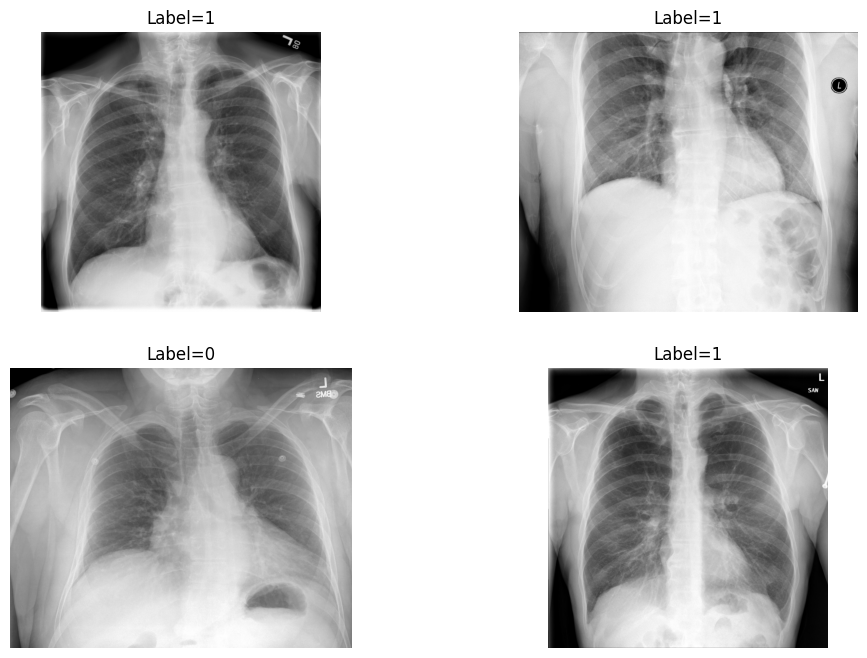

In [16]:
import matplotlib.pyplot as plt
from PIL import Image

sample = frontal_df.sample(
    4,
    random_state=42
)

plt.figure(figsize=(12,8))

for i, (_, row) in enumerate(
    sample.iterrows()
):

    img = Image.open(
        row["image_path"]
    )

    plt.subplot(
        2,
        2,
        i+1
    )

    plt.imshow(
        img,
        cmap="gray"
    )

    plt.title(
        f"Label={row['label']}"
    )

    plt.axis("off")

plt.show()

In [17]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    frontal_df,
    test_size=0.2,
    stratify=frontal_df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["label"],
    random_state=42
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 3054
Validation: 382
Test: 382


In [18]:
!pip install timm -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 92.2 MB/s eta 0:00:00:00:01:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which 

In [19]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

from torchvision import transforms
from PIL import Image

import numpy as np

In [20]:
train_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(10),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

test_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [21]:
class IUXrayDataset(Dataset):

    def __init__(
        self,
        dataframe,
        transform=None
    ):

        self.df = dataframe.reset_index(
            drop=True
        )

        self.transform = transform

    def __len__(self):

        return len(self.df)

    def __getitem__(
        self,
        idx
    ):

        row = self.df.iloc[idx]

        image = Image.open(
            row["image_path"]
        )

        image = image.convert(
            "RGB"
        )

        if self.transform:

            image = self.transform(
                image
            )

        label = int(
            row["label"]
        )

        return image, label

In [22]:
train_dataset = IUXrayDataset(
    train_df,
    train_transform
)

val_dataset = IUXrayDataset(
    val_df,
    test_transform
)

test_dataset = IUXrayDataset(
    test_df,
    test_transform
)

print(
    len(train_dataset),
    len(val_dataset),
    len(test_dataset)
)

3054 382 382


In [23]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

print("Loaders Ready")

Loaders Ready


In [24]:
images, labels = next(
    iter(train_loader)
)

print(
    images.shape
)

print(
    labels.shape
)

torch.Size([32, 3, 224, 224])
torch.Size([32])


In [25]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F


class ArcFace(nn.Module):

    def __init__(
        self,
        in_features,
        out_features,
        s=30.0,
        m=0.50
    ):

        super().__init__()

        self.weight = nn.Parameter(
            torch.FloatTensor(
                out_features,
                in_features
            )
        )

        nn.init.xavier_uniform_(
            self.weight
        )

        self.s = s
        self.m = m

    def forward(
        self,
        features,
        labels
    ):

        cosine = F.linear(
            F.normalize(features),
            F.normalize(self.weight)
        )

        theta = torch.acos(
            torch.clamp(
                cosine,
                -1 + 1e-7,
                1 - 1e-7
            )
        )

        target_logits = torch.cos(
            theta + self.m
        )

        one_hot = torch.zeros_like(
            cosine
        )

        one_hot.scatter_(
            1,
            labels.view(-1,1),
            1
        )

        logits = (
            one_hot * target_logits
            +
            (1-one_hot) * cosine
        )

        logits *= self.s

        return logits

In [26]:
from torchvision import models


class DenseNetArcFace(nn.Module):

    def __init__(self):

        super().__init__()

        self.backbone = models.densenet121(
            weights="DEFAULT"
        )

        num_features = (
            self.backbone.classifier
            .in_features
        )

        self.backbone.classifier = nn.Identity()

        self.dropout = nn.Dropout(
            p=0.30
        )

        self.arcface = ArcFace(
            num_features,
            2
        )

    def forward(
        self,
        images,
        labels=None
    ):

        features = self.backbone(
            images
        )

        features = self.dropout(
            features
        )

        if labels is not None:

            logits = self.arcface(
                features,
                labels
            )

            return logits

        return features

In [27]:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

model = DenseNetArcFace().to(
    device
)

print(device)
print(model.__class__.__name__)

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 131MB/s] 


cuda
DenseNetArcFace


In [28]:
criterion = nn.CrossEntropyLoss()

print("Loss Ready")

Loss Ready


In [29]:
import torch.optim as optim

optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

print("Optimizer Ready")

Optimizer Ready


In [30]:
scheduler = (
    optim.lr_scheduler
    .ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=2
    )
)

print("Scheduler Ready")

Scheduler Ready


In [31]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [32]:
def evaluate_model(
    model,
    loader
):

    model.eval()

    preds_all = []
    labels_all = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(
                images,
                labels
            )

            preds = outputs.argmax(1)

            preds_all.extend(
                preds.cpu().numpy()
            )

            labels_all.extend(
                labels.cpu().numpy()
            )

    acc = accuracy_score(
        labels_all,
        preds_all
    )

    precision = precision_score(
        labels_all,
        preds_all
    )

    recall = recall_score(
        labels_all,
        preds_all
    )

    f1 = f1_score(
        labels_all,
        preds_all
    )

    return (
        acc,
        precision,
        recall,
        f1
    )

In [33]:
EPOCHS = 15

best_f1 = 0

print("Training Ready")

Training Ready


In [34]:
from tqdm import tqdm

for epoch in range(EPOCHS):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    loop = tqdm(
        train_loader,
        leave=True
    )

    for images, labels in loop:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(
            images,
            labels
        )

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        preds = outputs.argmax(1)

        correct += (
            preds == labels
        ).sum().item()

        total += labels.size(0)

    train_acc = correct / total

    (
        val_acc,
        precision,
        recall,
        f1
    ) = evaluate_model(
        model,
        val_loader
    )

    scheduler.step(
        val_acc
    )

    print(
        f"\nEpoch {epoch+1}"
    )

    print(
        f"Train Loss: {running_loss/len(train_loader):.4f}"
    )

    print(
        f"Train Acc : {train_acc:.4f}"
    )

    print(
        f"Val Acc   : {val_acc:.4f}"
    )

    print(
        f"Precision : {precision:.4f}"
    )

    print(
        f"Recall    : {recall:.4f}"
    )

    print(
        f"F1 Score  : {f1:.4f}"
    )

    if f1 > best_f1:

        best_f1 = f1

        torch.save(
            model.state_dict(),
            "best_arcface_iu.pth"
        )

        print(
            "Best Model Saved"
        )

100%|██████████| 96/96 [02:25<00:00,  1.52s/it]



Epoch 1
Train Loss: 10.4488
Train Acc : 0.1997
Val Acc   : 0.5419
Precision : 0.6104
Recall    : 0.7737
F1 Score  : 0.6824
Best Model Saved


100%|██████████| 96/96 [01:57<00:00,  1.22s/it]



Epoch 2
Train Loss: 7.9507
Train Acc : 0.4565
Val Acc   : 0.6309
Precision : 0.6645
Recall    : 0.8477
F1 Score  : 0.7450
Best Model Saved


100%|██████████| 96/96 [01:57<00:00,  1.22s/it]


...


Epoch 13
Train Loss: 3.5135
Train Acc : 0.7014
Val Acc   : 0.6440
Precision : 0.7115
Recall    : 0.7407
F1 Score  : 0.7258


100%|██████████| 96/96 [01:57<00:00,  1.22s/it]



Epoch 14
Train Loss: 3.0483
Train Acc : 0.7220
Val Acc   : 0.6571
Precision : 0.7205
Recall    : 0.7531
F1 Score  : 0.7364


100%|██████████| 96/96 [01:57<00:00,  1.22s/it]



Epoch 15
Train Loss: 3.1005
Train Acc : 0.7213
Val Acc   : 0.6361
Precision : 0.7131
Recall    : 0.7160
F1 Score  : 0.7146


In [35]:
model.load_state_dict(
    torch.load(
        "best_arcface_iu.pth",
        map_location=device
    )
)

print("Best Model Loaded")

Best Model Loaded


In [36]:
test_acc, precision, recall, f1 = (
    evaluate_model(
        model,
        test_loader
    )
)

print("\nFINAL TEST RESULTS")

print(
    "Accuracy  :",
    round(test_acc,4)
)

print(
    "Precision :",
    round(precision,4)
)

print(
    "Recall    :",
    round(recall,4)
)

print(
    "F1 Score  :",
    round(f1,4)
)


FINAL TEST RESULTS
Accuracy  : 0.6545
Precision : 0.6785
Recall    : 0.8683
F1 Score  : 0.7617


In [37]:
from sklearn.metrics import confusion_matrix

model.eval()

preds_all = []
labels_all = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(
            images,
            labels
        )

        preds = outputs.argmax(1)

        preds_all.extend(
            preds.cpu().numpy()
        )

        labels_all.extend(
            labels.cpu().numpy()
        )

cm = confusion_matrix(
    labels_all,
    preds_all
)

print(cm)

[[ 39 100]
 [ 32 211]]


In [38]:
from torchvision import models
import torch.nn as nn


class DenseNetSoftmax(nn.Module):

    def __init__(self):

        super().__init__()

        self.model = models.densenet121(
            weights="DEFAULT"
        )

        num_features = (
            self.model.classifier
            .in_features
        )

        self.model.classifier = nn.Sequential(

            nn.Dropout(0.3),

            nn.Linear(
                num_features,
                2
            )
        )

    def forward(
        self,
        x
    ):

        return self.model(x)

In [39]:
softmax_model = (
    DenseNetSoftmax()
    .to(device)
)

criterion_softmax = (
    nn.CrossEntropyLoss()
)

optimizer_softmax = (
    torch.optim.AdamW(
        softmax_model.parameters(),
        lr=1e-4
    )
)

print(
    "Softmax Model Ready"
)

Softmax Model Ready


In [40]:
def evaluate_softmax(
    model,
    loader
):

    model.eval()

    preds_all = []
    labels_all = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)

            labels = labels.to(device)

            outputs = model(
                images
            )

            preds = outputs.argmax(1)

            preds_all.extend(
                preds.cpu().numpy()
            )

            labels_all.extend(
                labels.cpu().numpy()
            )

    acc = accuracy_score(
        labels_all,
        preds_all
    )

    precision = precision_score(
        labels_all,
        preds_all
    )

    recall = recall_score(
        labels_all,
        preds_all
    )

    f1 = f1_score(
        labels_all,
        preds_all
    )

    return (
        acc,
        precision,
        recall,
        f1
    )

In [41]:
best_softmax_f1 = 0

for epoch in range(10):

    softmax_model.train()

    running_loss = 0

    for images, labels in tqdm(
        train_loader
    ):

        images = images.to(device)

        labels = labels.to(device)

        optimizer_softmax.zero_grad()

        outputs = softmax_model(
            images
        )

        loss = criterion_softmax(
            outputs,
            labels
        )

        loss.backward()

        optimizer_softmax.step()

        running_loss += (
            loss.item()
        )

    (
        val_acc,
        precision,
        recall,
        f1
    ) = evaluate_softmax(
        softmax_model,
        val_loader
    )

    print(
        f"\nEpoch {epoch+1}"
    )

    print(
        f"Val Acc : {val_acc:.4f}"
    )

    print(
        f"F1      : {f1:.4f}"
    )

    if f1 > best_softmax_f1:

        best_softmax_f1 = f1

        torch.save(
            softmax_model.state_dict(),
            "best_softmax_iu.pth"
        )

100%|██████████| 96/96 [02:01<00:00,  1.26s/it]



Epoch 1
Val Acc : 0.7147
F1      : 0.7686


100%|██████████| 96/96 [01:59<00:00,  1.25s/it]



Epoch 2
Val Acc : 0.7487
F1      : 0.8080


100%|██████████| 96/96 [01:59<00:00,  1.24s/it]


...


Epoch 8
Val Acc : 0.6911
F1      : 0.7269


100%|██████████| 96/96 [01:58<00:00,  1.23s/it]



Epoch 9
Val Acc : 0.7094
F1      : 0.7739


100%|██████████| 96/96 [01:56<00:00,  1.22s/it]



Epoch 10
Val Acc : 0.6545
F1      : 0.7582


In [42]:
softmax_model.load_state_dict(
    torch.load(
        "best_softmax_iu.pth",
        map_location=device
    )
)

softmax_acc, softmax_precision, softmax_recall, softmax_f1 = (
    evaluate_softmax(
        softmax_model,
        test_loader
    )
)

print(
    "\nSOFTMAX RESULTS"
)

print(
    "Accuracy:",
    softmax_acc
)

print(
    "Precision:",
    softmax_precision
)

print(
    "Recall:",
    softmax_recall
)

print(
    "F1:",
    softmax_f1
)


SOFTMAX RESULTS
Accuracy: 0.7198952879581152
Precision: 0.753731343283582
Recall: 0.831275720164609
F1: 0.7906066536203522


In [43]:
comparison = pd.DataFrame({

    "Model":[
        "DenseNet121 + Softmax",
        "DenseNet121 + ArcFace"
    ],

    "Accuracy":[
        softmax_acc*100,
        test_acc*100
    ],

    "Precision":[
        softmax_precision*100,
        precision*100
    ],

    "Recall":[
        softmax_recall*100,
        recall*100
    ],

    "F1":[
        softmax_f1*100,
        f1*100
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1
0,DenseNet121 + Softmax,71.989529,75.373134,83.127572,79.060665
1,DenseNet121 + ArcFace,65.445026,68.316832,85.185185,75.824176


In [44]:
def enable_dropout(model):

    for m in model.modules():

        if isinstance(
            m,
            nn.Dropout
        ):
            m.train()

In [45]:
import numpy as np
import torch


def mc_dropout_predict(
    model,
    image,
    T=30
):

    model.eval()

    enable_dropout(model)

    predictions = []

    with torch.no_grad():

        for _ in range(T):

            features = model(
                image
            )

            probs = torch.softmax(
                features,
                dim=1
            )

            predictions.append(
                probs.cpu().numpy()
            )

    predictions = np.array(
        predictions
    )

    mean_prediction = np.mean(
        predictions,
        axis=0
    )

    uncertainty = np.std(
        predictions,
        axis=0
    )

    return (
        mean_prediction,
        uncertainty
    )

In [46]:
sample_img, sample_label = (
    test_dataset[0]
)

sample_img = (
    sample_img
    .unsqueeze(0)
    .to(device)
)

mean_pred, uncertainty = (
    mc_dropout_predict(
        softmax_model,
        sample_img,
        T=30
    )
)

print(
    "Mean Prediction"
)

print(mean_pred)

print(
    "\nUncertainty"
)

print(uncertainty)

Mean Prediction
[[0.40755364 0.59244627]]

Uncertainty
[[0.08636319 0.0863632 ]]


In [47]:
UNCERTAINTY_THRESHOLD = 0.05

uncertainty_score = np.max(
    uncertainty
)

print(
    "Uncertainty:",
    uncertainty_score
)

if uncertainty_score > UNCERTAINTY_THRESHOLD:

    print(
        "REFER TO RADIOLOGIST"
    )

else:

    print(
        "AI DECISION ACCEPTED"
    )

Uncertainty: 0.0863632
REFER TO RADIOLOGIST


In [48]:
results = []

for i in range(100):

    image, label = (
        test_dataset[i]
    )

    image = (
        image
        .unsqueeze(0)
        .to(device)
    )

    mean_pred, uncertainty = (
        mc_dropout_predict(
            softmax_model,
            image,
            T=30
        )
    )

    pred = np.argmax(
        mean_pred
    )

    score = np.max(
        uncertainty
    )

    decision = (
        "Refer"
        if score > 0.05
        else "Accept"
    )

    results.append([
        i,
        pred,
        label,
        score,
        decision
    ])

uncertainty_df = pd.DataFrame(

    results,

    columns=[
        "Index",
        "Prediction",
        "Actual",
        "Uncertainty",
        "Decision"
    ]
)

uncertainty_df.head(20)

,Index,Prediction,Actual,Uncertainty,Decision
0,0,1,0,0.079014,Refer
1,1,1,1,0.038120,Accept
2,2,1,1,0.087627,Refer
3,3,1,1,0.093084,Refer
4,4,1,1,0.037476,Accept
5,5,0,0,0.087815,Refer
6,6,1,1,0.050713,Refer
7,7,0,0,0.067524,Refer
8,8,1,1,0.008960,Accept
9,9,0,0,0.086371,Refer


In [49]:
uncertainty_df[
    "Decision"
].value_counts()

Decision
Refer     64
Accept    36
Name: count, dtype: int64

In [50]:
correct_uncertainty = []
wrong_uncertainty = []

for i in range(100):

    image, label = test_dataset[i]

    image = image.unsqueeze(0).to(device)

    mean_pred, uncertainty = (
        mc_dropout_predict(
            softmax_model,
            image,
            T=30
        )
    )

    pred = np.argmax(mean_pred)

    score = np.max(uncertainty)

    if pred == label:

        correct_uncertainty.append(
            score
        )

    else:

        wrong_uncertainty.append(
            score
        )

print(
    "Average Correct Uncertainty:",
    np.mean(correct_uncertainty)
)

print(
    "Average Wrong Uncertainty:",
    np.mean(wrong_uncertainty)
)

Average Correct Uncertainty: 0.06037137
Average Wrong Uncertainty: 0.059391025


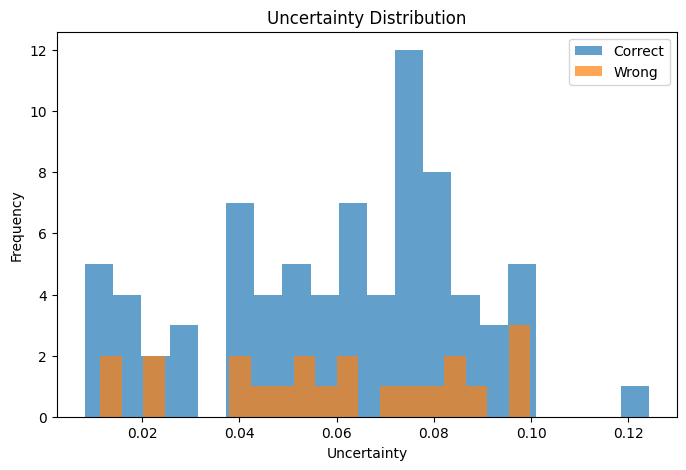

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    correct_uncertainty,
    bins=20,
    alpha=0.7,
    label="Correct"
)

plt.hist(
    wrong_uncertainty,
    bins=20,
    alpha=0.7,
    label="Wrong"
)

plt.xlabel(
    "Uncertainty"
)

plt.ylabel(
    "Frequency"
)

plt.legend()

plt.title(
    "Uncertainty Distribution"
)

plt.show()

In [52]:
uncertainty_df.to_csv(
    "referral_results.csv",
    index=False
)

uncertainty_df.head(20)

,Index,Prediction,Actual,Uncertainty,Decision
0,0,1,0,0.079014,Refer
1,1,1,1,0.038120,Accept
2,2,1,1,0.087627,Refer
3,3,1,1,0.093084,Refer
4,4,1,1,0.037476,Accept
5,5,0,0,0.087815,Refer
6,6,1,1,0.050713,Refer
7,7,0,0,0.067524,Refer
8,8,1,1,0.008960,Accept
9,9,0,0,0.086371,Refer


In [53]:
print("="*60)

print("PROPOSED FRAMEWORK")

print("="*60)

print("1. DenseNet121 Feature Extraction")

print("2. Softmax Classification")

print("3. MC Dropout Uncertainty Estimation")

print("4. Radiologist Referral Mechanism")

print("5. Grad-CAM Explainability")

print("="*60)

PROPOSED FRAMEWORK
1. DenseNet121 Feature Extraction
2. Softmax Classification
3. MC Dropout Uncertainty Estimation
4. Radiologist Referral Mechanism
5. Grad-CAM Explainability
